In [ ]:
!pip install kumoai

In [ ]:
!gcloud auth application-default login

Go to the following link in your browser, and complete the sign-in prompts:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=https%3A%2F%2Fsdk.cloud.google.com%2Fapplicationdefaultauthcode.html&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=kQJMPLfavON8jZgRkhx7zbETT1qcY8&prompt=consent&token_usage=remote&access_type=offline&code_challenge=d-q6yeUTt6ePkrbY5Vf5YuEWOOwgiJFl4G1ovy8aNP0&code_challenge_method=S256

Once finished, enter the verification code provided in your browser: 4/0AdkVLPzzvkBik3Rc9U-eF6c3-KrOtNxzLpnLfDJKo7Mj8TgHdJd7iGQVNSXNOp3HRCddag

Credentials saved to file: [/content/.config/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).
Ca

In [ ]:
import os
import kumoai.experimental.rfm as rfm, os
import pandas as pd

from google.cloud import bigquery

In [ ]:
KUMO_API_KEY = os.environ.get("KUMO_API_KEY")
rfm.init(api_key=KUMO_API_KEY)

INFO:kumoai:Initialized Kumo SDK v2.22.0 against deployment 'https://kumorfm.ai/api'


In [18]:
client = bigquery.Client(project="diesel-charge-465712-f8")

# Cohort
cohort_query = """
WITH cohort AS (
  SELECT
    subject_id,
    hadm_id,
    stay_id,
    intime
  FROM `physionet-data.mimiciv_3_1_icu.icustays`
  WHERE RAND() < 0.05
)
SELECT * FROM cohort
"""

cohort_df = client.query(cohort_query).to_dataframe()

stay_ids = cohort_df["stay_id"].tolist()
hadm_ids = cohort_df["hadm_id"].dropna().unique().tolist()
subject_ids = cohort_df["subject_id"].dropna().unique().tolist()


# Admissions
admissions_query = """
SELECT hadm_id, subject_id, deathtime, admittime, dischtime
FROM `physionet-data.mimiciv_3_1_hosp.admissions`
WHERE hadm_id IN UNNEST(@hadm_ids)
"""

admissions_df = client.query(
    admissions_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)]
    )
).to_dataframe()


# Patients
patients_query = """
SELECT subject_id, gender, anchor_age, anchor_year
FROM `physionet-data.mimiciv_3_1_hosp.patients`
WHERE subject_id IN UNNEST(@subject_ids)
"""

patients_df = client.query(
    patients_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("subject_ids", "INT64", subject_ids)]
    )
).to_dataframe()


# ICU Stays
icustays_query = """
SELECT stay_id, hadm_id, subject_id, intime, outtime, los
FROM `physionet-data.mimiciv_3_1_icu.icustays`
WHERE stay_id IN UNNEST(@stay_ids)
"""

icustays_df = client.query(
    icustays_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("stay_ids", "INT64", stay_ids)]
    )
).to_dataframe()


# Labevents
labevents_query = """
SELECT l.*
FROM `physionet-data.mimiciv_3_1_hosp.labevents` l
INNER JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
  ON l.hadm_id = i.hadm_id
WHERE l.subject_id IN UNNEST(@subject_ids)
"""

labevents_df = client.query(
    labevents_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("subject_ids", "INT64", subject_ids)]
    )
).to_dataframe()

# Diagnoses
diagnoses_query = """
SELECT hadm_id, subject_id, seq_num, icd_code, icd_version
FROM `physionet-data.mimiciv_3_1_hosp.diagnoses_icd`
WHERE hadm_id IN UNNEST(@hadm_ids)
"""

diagnoses_df = client.query(
    diagnoses_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)]
    )
).to_dataframe()


# Prescriptions
prescriptions_query = """
SELECT hadm_id, subject_id, drug, route, starttime, stoptime
FROM `physionet-data.mimiciv_3_1_hosp.prescriptions`
WHERE hadm_id IN UNNEST(@hadm_ids)
"""

prescriptions_df = client.query(
    prescriptions_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("hadm_ids", "INT64", hadm_ids)]
    )
).to_dataframe()


# Chartevents
chartevents_query = """
SELECT c.stay_id, c.subject_id, c.itemid, c.valuenum, c.valueuom, c.charttime
FROM `physionet-data.mimiciv_3_1_icu.chartevents` c
INNER JOIN `physionet-data.mimiciv_3_1_icu.icustays` i
  ON c.stay_id = i.stay_id
WHERE c.stay_id IN UNNEST(@stay_ids)
"""

chartevents_df = client.query(
    chartevents_query,
    job_config=bigquery.QueryJobConfig(
        query_parameters=[bigquery.ArrayQueryParameter("stay_ids", "INT64", stay_ids)]
    )
).to_dataframe()

chartevents_df = chartevents_df.reset_index().rename(columns={'index': 'chartevent_id'})
prescriptions_df = prescriptions_df.reset_index().rename(columns={'index': 'prescription_id'})
diagnoses_df = diagnoses_df.reset_index().rename(columns={'index': 'diagnoses_icd_id'})

icustays_df = icustays_df.merge(
    admissions_df[['hadm_id', 'deathtime']],
    on='hadm_id',
    how='left'
)

icustays_df['intime'] = pd.to_datetime(icustays_df['intime'])
icustays_df['deathtime'] = pd.to_datetime(icustays_df['deathtime'])

icustays_df['died_within_48h'] = (
    icustays_df['deathtime'].notna() &
    ((icustays_df['deathtime'] - icustays_df['intime']).dt.total_seconds() / 3600.0 <= 48.0)
).astype(int)

SyntaxError: incomplete input (3054824291.py, line 143)

In [ ]:
len(patients_df) + len(admissions_df) + len(icustays_df) + len(labevents_df) + len(diagnoses_df) + len(prescriptions_df) + len(chartevents_df)

27635918

In [ ]:
tables_dict = {
    'patients': patients_df,
    'admissions': admissions_df,
    'icustays': icustays_df,
    'labevents': labevents_df,
    'diagnoses_icd': diagnoses_df,
    'prescriptions': prescriptions_df,
    'chartevents': chartevents_df
}

In [ ]:
def preprocess_tables_dict(tables_dict):
    for table_name, df in tables_dict.items():
      dbdate_columns = df.dtypes[df.dtypes == 'dbdate'].index.tolist()
      for col in dbdate_columns:
        df[col] = pd.to_datetime(df[col])

    return tables_dict

In [ ]:
tables_dict = preprocess_tables_dict(tables_dict)

In [ ]:
def transform_to_rfm_table(tables_dict):
  result = {}
  for table_name, df in tables_dict.items():
    rfm_table = rfm.LocalTable(
      df = df,
      name = table_name
    ).infer_metadata()
    result[table_name] = rfm_table
  return result

Inferred time column `admittime` for table `admissions`

Inferred time column `intime` for table `icustays`

Inferred primary key `labevent_id` and time column `charttime` for table `labevents`

Inferred primary key `diagnoses_icd_id` for table `diagnoses_icd`

Inferred primary key `prescription_id` and time column `starttime` for table `prescriptions`

Inferred primary key `chartevent_id` and time column `charttime` for table `chartevents`

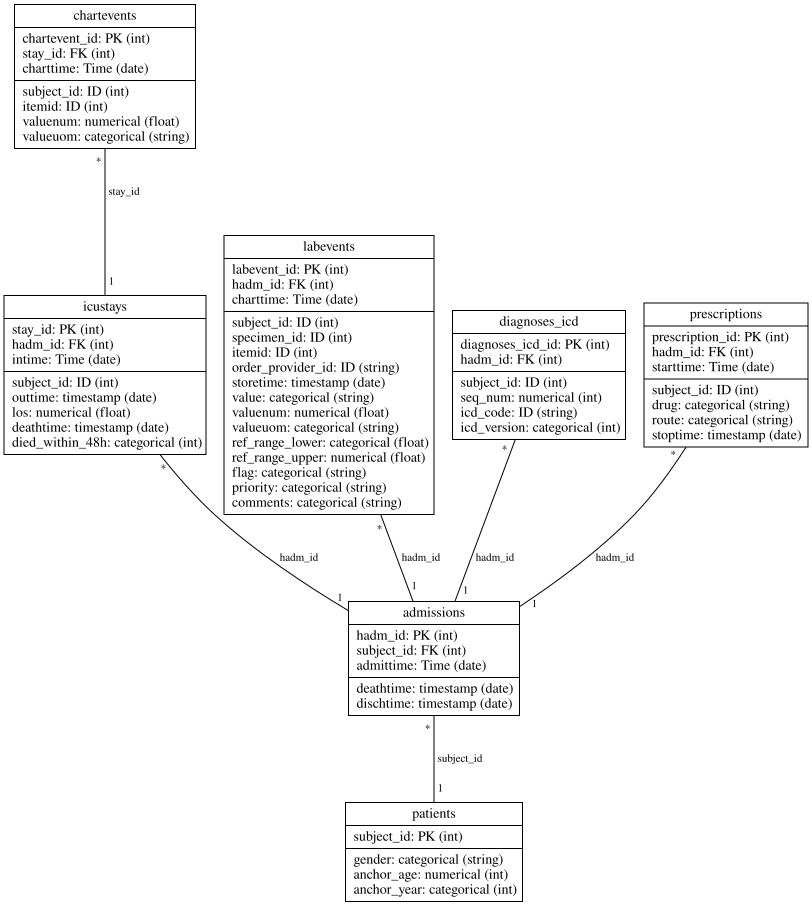

Output()

In [ ]:
tables = transform_to_rfm_table(tables_dict)

tables['patients'].primary_key = "subject_id"
tables['admissions'].primary_key = "hadm_id"
tables['icustays'].primary_key = "stay_id"
tables['labevents'].primary_key = "labevent_id"
tables['diagnoses_icd'].primary_key = "diagnoses_icd_id"
tables['prescriptions'].primary_key = "prescription_id"
tables['chartevents'].primary_key = "chartevent_id"

graph = rfm.LocalGraph(tables=tables.values())

graph.link(src_table="admissions", fkey="subject_id", dst_table="patients")
graph.link(src_table="icustays", fkey="hadm_id", dst_table="admissions")
graph.link(src_table="labevents", fkey="hadm_id", dst_table="admissions")
graph.link(src_table="diagnoses_icd", fkey="hadm_id", dst_table="admissions")
graph.link(src_table="prescriptions", fkey="hadm_id", dst_table="admissions")
graph.link(src_table="chartevents",   fkey="stay_id", dst_table="icustays")

graph.visualize()

In [ ]:
model = rfm.KumoRFM(graph=graph)

Output()

In [ ]:
query = """
PREDICT icustays.died_within_48h
FOR EACH icustays.stay_id
"""

patient_ids = tables_dict['icustays']['stay_id'].dropna().astype(int).tolist()

with model.batch_mode(batch_size="max", num_retries=1):
    try:
        df = model.predict(query, indices=patient_ids)
        display(df.head())
    except Exception as e:
        print(f"Error: {e}")

Output()

,ENTITY,ANCHOR_TIMESTAMP,CLASS,SCORE,PREDICTED
0,35854639,2214-05-12 12:00:00,0,0.999817,True
1,35854639,2214-05-12 12:00:00,1,0.000183,False
2,37101984,2214-05-12 12:00:00,0,0.788583,True
3,37101984,2214-05-12 12:00:00,1,0.211417,False
4,33337491,2214-05-12 12:00:00,0,0.999958,True


In [ ]:
metrics = model.evaluate(
    query,
    metrics=['acc', 'precision', 'recall', 'f1', 'mrr']
)

metrics

Output()

,metric,value
0,acc,0.964500
1,f1,0.767487
2,mrr,0.982500
3,precision,0.815942
4,recall,0.733103


In [ ]:
num_samples = 1
sample_stay_ids = tables_dict['icustays']['stay_id'].dropna().astype(int).head(num_samples).tolist()

print(f"Generating explanations for {len(sample_stay_ids)} ICU stays...")
for stay_id in sample_stay_ids:
    try:
        explanation_df = model.predict(query, indices=[stay_id], explain=True)

        print(f"Stay: {stay_id}")
        print(explanation_df)

    except Exception as e:
        print(f"Could not explain stay_id {stay_id}: {e}")

Generating explanations for 1 ICU stays...


Output()

Stay: 35854639


╭──────────┬─────────────────────┬───────┬──────────────┬───────────╮
│ ENTITY   │ ANCHOR_TIMESTAMP    │ CLASS │ SCORE        │ PREDICTED │
├──────────┼─────────────────────┼───────┼──────────────┼───────────┤
│ 35854639 │ 2214-05-12 12:00:00 │ 0     │ 0.9998107553 │ ✅        │
│ 35854639 │ 2214-05-12 12:00:00 │ 1     │ 0.0001892475 │ -         │
╰──────────┴─────────────────────┴───────┴──────────────┴───────────╯
The model predicts that the ICU stay with stay_id 35854639 has a very high risk of death within 48 hours, marking the outcome as "true" with an extremely high confidence score of 0.9998.

Looking into the explanation:

 1 Global Pattern Insights (Column Analysis):                                                                      
    • The overall population experiences a low event rate (~4.7% die within 48h across cohorts).                   
    • Some diagnoses like "N179" (acute kidney failure) and "I10" (hypertension) have relatively higher death proba
    • In ICU s

In [ ]:
los_anchor_query = """
PREDICT icustays.los
FOR EACH icustays.stay_id
WHERE icustays.los IS NOT NULL
"""

stay_ids = tables_dict['icustays']['stay_id'].dropna().astype(int).tolist()

print(f"Generating predictions for {len(stay_ids)} ICU stays...")
with model.batch_mode(batch_size="max", num_retries=1):
    try:
        predictions_df = model.predict(los_anchor_query, indices=stay_ids)
        display(predictions_df.head(5))
    except Exception as e:
        print(f"Prediction Error: {e}")

Generating predictions for 4698 ICU stays...


Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,35854639,2214-05-12 12:00:00,2.544114
1,37101984,2214-05-12 12:00:00,2.064591
2,33337491,2214-05-12 12:00:00,2.277334
3,34888385,2214-05-12 12:00:00,2.154441
4,31097260,2214-05-12 12:00:00,1.476560


In [ ]:
metrics = model.evaluate(
    los_anchor_query,
    metrics=['mae', 'mape', 'mse', 'rmse', 'smape', 'r2']
)

metrics

Output()

,metric,value
0,mae,2.434054
1,mape,0.999377
2,mse,30.470278
3,r2,-0.076049
4,rmse,5.519989
5,smape,0.649491


In [ ]:
foundation_regression_query = """
PREDICT patients.anchor_age
FOR EACH patients.subject_id
WHERE patients.anchor_age IS NOT NULL
"""

subject_ids = tables_dict['patients']['subject_id'].dropna().astype(int).unique().tolist()

print("Generating predictions...")
with model.batch_mode(batch_size="max", num_retries=1):
    try:
        predictions_df = model.predict(foundation_regression_query, indices=subject_ids)
        display(predictions_df.head())
        print("Success! Predictions generated cleanly.")
    except Exception as e:
        print(f"Prediction Error: {e}")

Generating predictions...


Output()

,ENTITY,ANCHOR_TIMESTAMP,TARGET_PRED
0,16617539,2214-05-12 12:00:00,62.0
1,11587027,2214-05-12 12:00:00,64.0
2,15046509,2214-05-12 12:00:00,61.0
3,13840723,2214-05-12 12:00:00,61.0
4,19777874,2214-05-12 12:00:00,36.0


Success! Predictions generated cleanly.


In [ ]:
metrics = model.evaluate(
    foundation_regression_query,
    metrics=['mae', 'mape', 'mse', 'rmse', 'smape', 'r2']
)

metrics

Output()

,metric,value
0,mae,13.575296
1,mape,0.271383
2,mse,284.785492
3,r2,-0.042498
4,rmse,16.875589
5,smape,0.227866
